<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [5]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [3]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




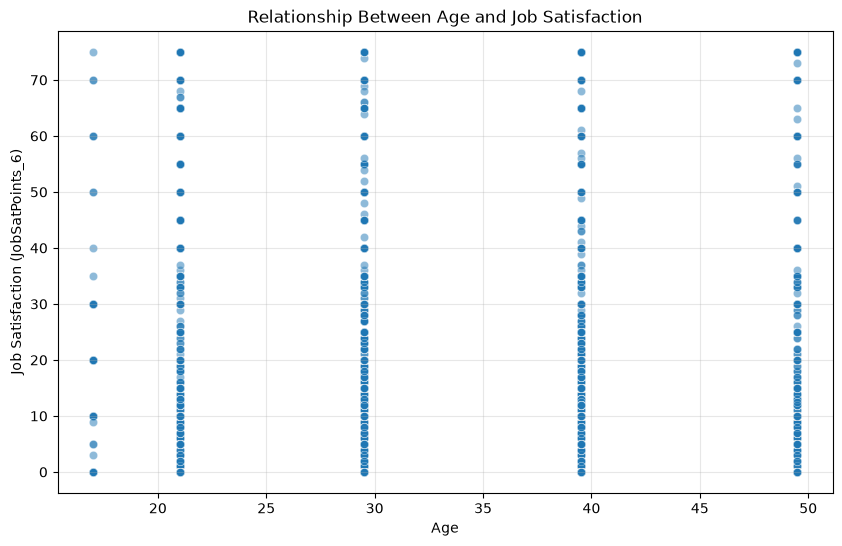

In [6]:
# Keep only relevant columns
age_df = df[['Age', 'JobSatPoints_6']].copy()

# Convert age groups to numeric midpoints
age_map = {
'Under 18 years old': 17,
'18-24 years old': 21,
'25-34 years old': 29.5,
'35-44 years old': 39.5,
'45-54 years old': 49.5,
'55-64 years old': 59.5,
'65 years or older': 67
}

age_df['AgeNumeric'] = age_df['Age'].map(age_map)

# Convert JobSatPoints_6 to numeric
age_df['JobSatPoints_6'] = pd.to_numeric(
age_df['JobSatPoints_6'],
errors='coerce'
)

# Remove missing values
age_df = age_df.dropna(subset=['AgeNumeric', 'JobSatPoints_6'])

# ----- Remove outliers using IQR -----

# Age
Q1_age = age_df['AgeNumeric'].quantile(0.25)
Q3_age = age_df['AgeNumeric'].quantile(0.75)
IQR_age = Q3_age - Q1_age

# JobSatPoints_6
Q1_js = age_df['JobSatPoints_6'].quantile(0.25)
Q3_js = age_df['JobSatPoints_6'].quantile(0.75)
IQR_js = Q3_js - Q1_js

age_df_clean = age_df[
(age_df['AgeNumeric'] >= Q1_age - 1.5 * IQR_age) &
(age_df['AgeNumeric'] <= Q3_age + 1.5 * IQR_age) &
(age_df['JobSatPoints_6'] >= Q1_js - 1.5 * IQR_js) &
(age_df['JobSatPoints_6'] <= Q3_js + 1.5 * IQR_js)
]

# ----- Scatter Plot -----

plt.figure(figsize=(10, 6))

sns.scatterplot(
data=age_df_clean,
x='AgeNumeric',
y='JobSatPoints_6',
alpha=0.5
)

plt.title('Relationship Between Age and Job Satisfaction')
plt.xlabel('Age')
plt.ylabel('Job Satisfaction (JobSatPoints_6)')
plt.grid(True, alpha=0.3)

plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


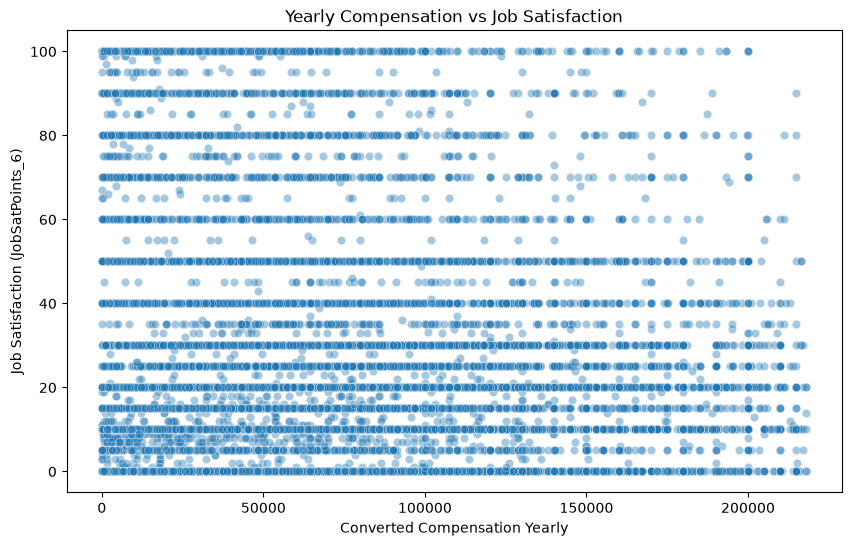

In [7]:
# Select relevant columns
comp_df = df[['ConvertedCompYearly', 'JobSatPoints_6']].copy()

# Convert to numeric
comp_df['ConvertedCompYearly'] = pd.to_numeric(
    comp_df['ConvertedCompYearly'],
    errors='coerce'
)

comp_df['JobSatPoints_6'] = pd.to_numeric(
    comp_df['JobSatPoints_6'],
    errors='coerce'
)

# Remove missing values
comp_df = comp_df.dropna()

# Remove compensation outliers using IQR
Q1 = comp_df['ConvertedCompYearly'].quantile(0.25)
Q3 = comp_df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

comp_df_clean = comp_df[
    (comp_df['ConvertedCompYearly'] >= Q1 - 1.5 * IQR) &
    (comp_df['ConvertedCompYearly'] <= Q3 + 1.5 * IQR)
]

# Scatter plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=comp_df_clean,
    x='ConvertedCompYearly',
    y='JobSatPoints_6',
    alpha=0.4
)

plt.title('Yearly Compensation vs Job Satisfaction')
plt.xlabel('Converted Compensation Yearly')
plt.ylabel('Job Satisfaction (JobSatPoints_6)')

plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


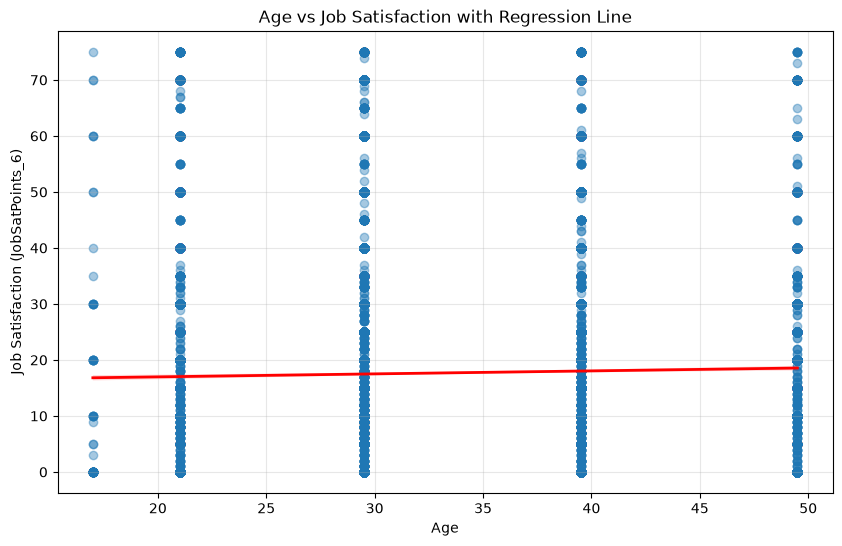

In [8]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=age_df_clean,
    x='AgeNumeric',
    y='JobSatPoints_6',
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title('Age vs Job Satisfaction with Regression Line')
plt.xlabel('Age')
plt.ylabel('Job Satisfaction (JobSatPoints_6)')
plt.grid(True, alpha=0.3)

plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


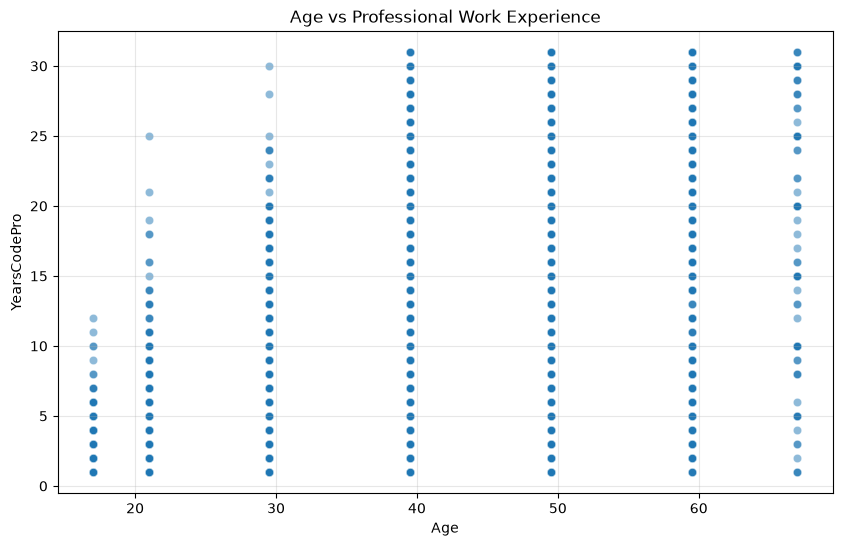

In [9]:
# Select relevant columns
age_work_df = df[['Age', 'YearsCodePro']].copy()

# Convert age groups to numeric midpoints
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 67
}

age_work_df['AgeNumeric'] = age_work_df['Age'].map(age_map)

# Convert YearsCodePro to numeric
age_work_df['YearsCodePro'] = pd.to_numeric(
    age_work_df['YearsCodePro'],
    errors='coerce'
)

# Remove missing values
age_work_df = age_work_df.dropna(
    subset=['AgeNumeric', 'YearsCodePro']
)

# Remove outliers from YearsCodePro using IQR
Q1 = age_work_df['YearsCodePro'].quantile(0.25)
Q3 = age_work_df['YearsCodePro'].quantile(0.75)
IQR = Q3 - Q1

age_work_df_clean = age_work_df[
    (age_work_df['YearsCodePro'] >= Q1 - 1.5 * IQR) &
    (age_work_df['YearsCodePro'] <= Q3 + 1.5 * IQR)
]

# Scatter plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=age_work_df_clean,
    x='AgeNumeric',
    y='YearsCodePro',
    alpha=0.5
)

plt.title('Age vs Professional Work Experience')
plt.xlabel('Age')
plt.ylabel('YearsCodePro')
plt.grid(True, alpha=0.3)

plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


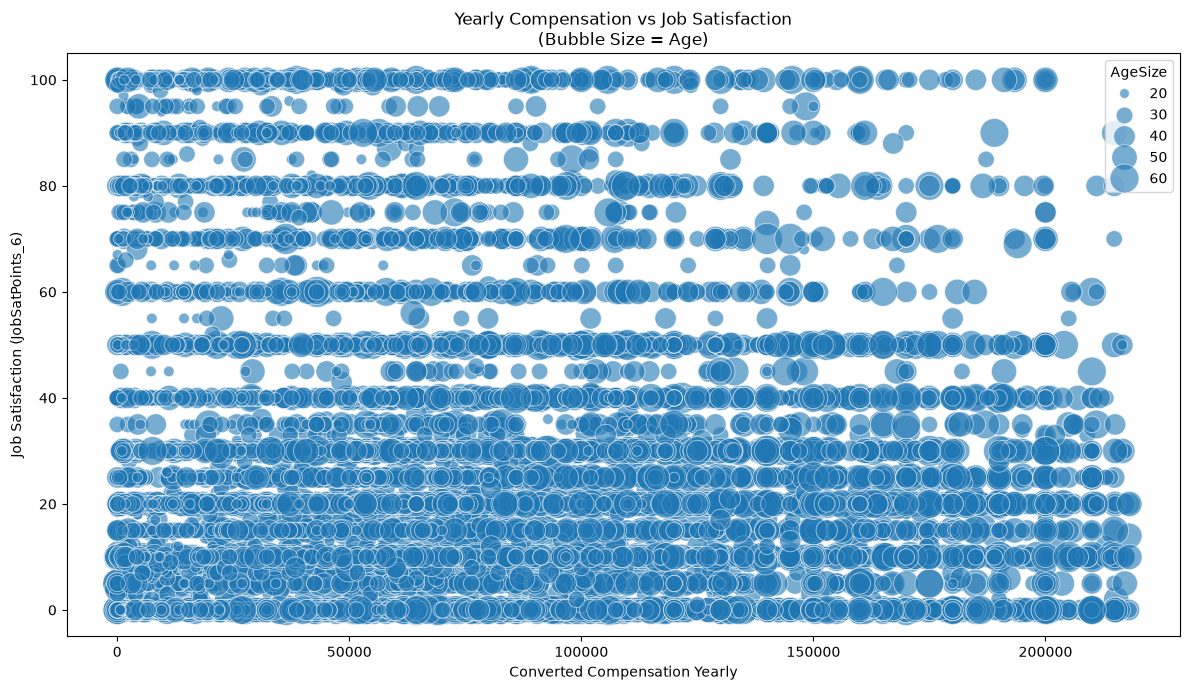

In [10]:
# Select relevant columns
bubble_df = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Age']].copy()

# Convert columns to numeric
bubble_df['ConvertedCompYearly'] = pd.to_numeric(
    bubble_df['ConvertedCompYearly'],
    errors='coerce'
)

bubble_df['JobSatPoints_6'] = pd.to_numeric(
    bubble_df['JobSatPoints_6'],
    errors='coerce'
)

# Convert Age groups to numeric midpoints for bubble size
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 67
}

bubble_df['AgeSize'] = bubble_df['Age'].map(age_map)

# Remove missing values
bubble_df = bubble_df.dropna()

# Remove compensation outliers using IQR
Q1 = bubble_df['ConvertedCompYearly'].quantile(0.25)
Q3 = bubble_df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

bubble_df_clean = bubble_df[
    (bubble_df['ConvertedCompYearly'] >= Q1 - 1.5 * IQR) &
    (bubble_df['ConvertedCompYearly'] <= Q3 + 1.5 * IQR)
]

# Bubble plot
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=bubble_df_clean,
    x='ConvertedCompYearly',
    y='JobSatPoints_6',
    size='AgeSize',
    sizes=(20, 500),
    alpha=0.6,
    legend='brief'
)

plt.title('Yearly Compensation vs Job Satisfaction\n(Bubble Size = Age)')
plt.xlabel('Converted Compensation Yearly')
plt.ylabel('Job Satisfaction (JobSatPoints_6)')

plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


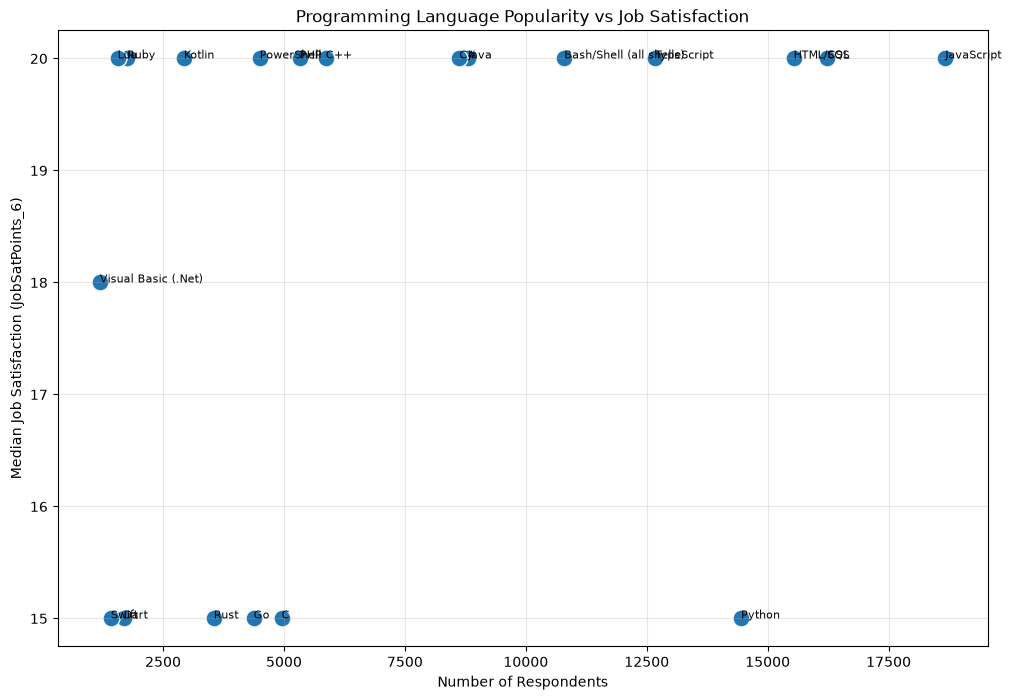

In [11]:
# Select relevant columns
lang_df = df[['LanguageHaveWorkedWith', 'JobSatPoints_6']].copy()

# Convert JobSatPoints_6 to numeric
lang_df['JobSatPoints_6'] = pd.to_numeric(
    lang_df['JobSatPoints_6'],
    errors='coerce'
)

# Remove missing values
lang_df = lang_df.dropna()

# Split languages into separate rows
lang_df = lang_df.assign(
    Language=lang_df['LanguageHaveWorkedWith'].str.split(';')
).explode('Language')

# Remove extra spaces
lang_df['Language'] = lang_df['Language'].str.strip()

# Calculate popularity and median job satisfaction
language_summary = (
    lang_df
    .groupby('Language')
    .agg(
        Respondents=('Language', 'count'),
        MedianJobSat=('JobSatPoints_6', 'median')
    )
    .reset_index()
)

# Keep top 20 most popular languages
language_summary = (
    language_summary
    .sort_values('Respondents', ascending=False)
    .head(20)
)

# Scatter plot
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=language_summary,
    x='Respondents',
    y='MedianJobSat',
    s=150
)

# Add language labels
for _, row in language_summary.iterrows():
    plt.annotate(
    row['Language'],
    (row['Respondents'], row['MedianJobSat']),
    fontsize=8
)

plt.title('Programming Language Popularity vs Job Satisfaction')
plt.xlabel('Number of Respondents')
plt.ylabel('Median Job Satisfaction (JobSatPoints_6)')
plt.grid(True, alpha=0.3)

plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


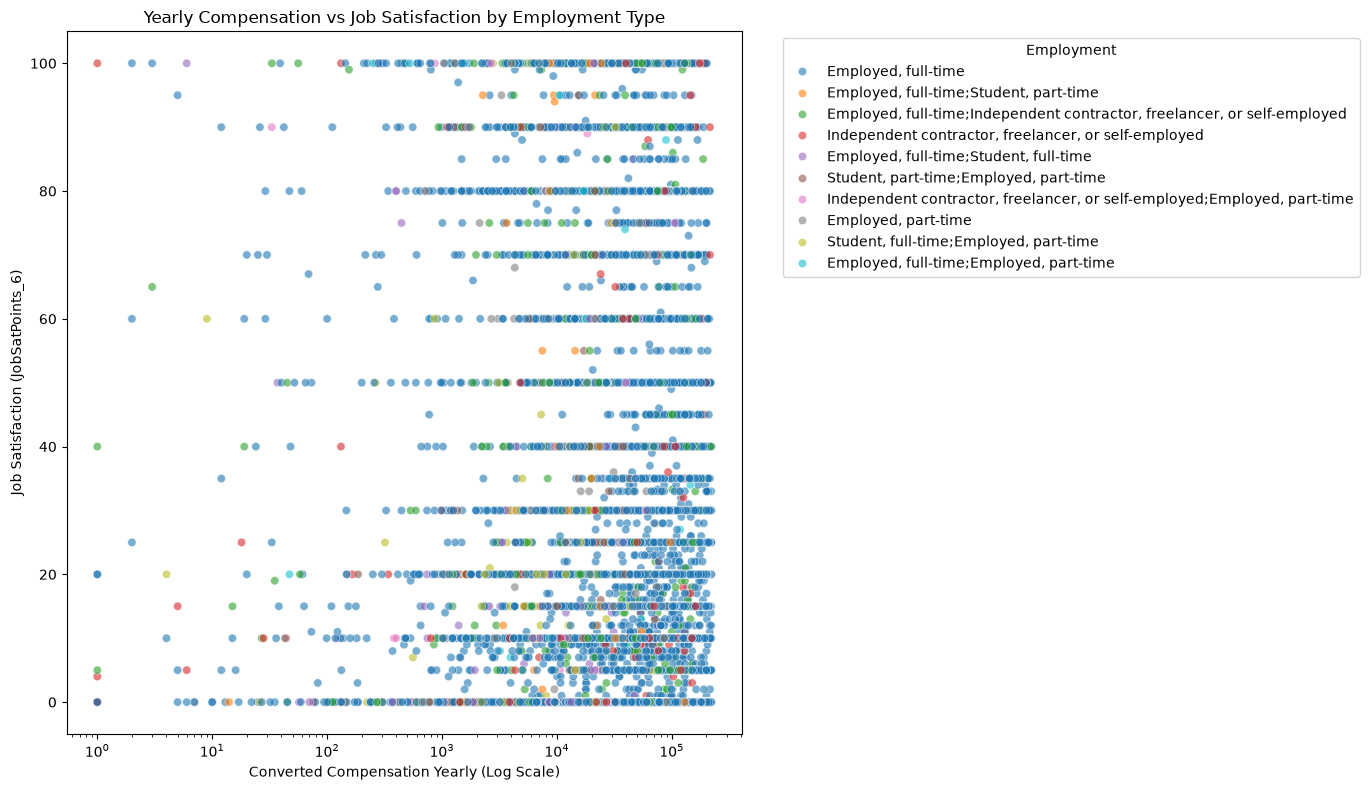

In [12]:
# Select relevant columns
emp_df = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Employment']].copy()

# Convert to numeric
emp_df['ConvertedCompYearly'] = pd.to_numeric(
    emp_df['ConvertedCompYearly'],
    errors='coerce'
)

emp_df['JobSatPoints_6'] = pd.to_numeric(
    emp_df['JobSatPoints_6'],
    errors='coerce'
)

# Remove missing values
emp_df = emp_df.dropna()

# Keep only the top 10 employment types
top_10_employment = emp_df['Employment'].value_counts().nlargest(10).index

emp_df = emp_df[
    emp_df['Employment'].isin(top_10_employment)
]

# Remove compensation outliers using IQR
Q1 = emp_df['ConvertedCompYearly'].quantile(0.25)
Q3 = emp_df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

emp_df_clean = emp_df[
    (emp_df['ConvertedCompYearly'] >= Q1 - 1.5 * IQR) &
    (emp_df['ConvertedCompYearly'] <= Q3 + 1.5 * IQR)
]

# Scatter plot
plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=emp_df_clean,
    x='ConvertedCompYearly',
    y='JobSatPoints_6',
    hue='Employment',
    alpha=0.6
)

plt.xscale('log')

plt.title('Yearly Compensation vs Job Satisfaction by Employment Type')
plt.xlabel('Converted Compensation Yearly (Log Scale)')
plt.ylabel('Job Satisfaction (JobSatPoints_6)')
plt.legend(
    title='Employment',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


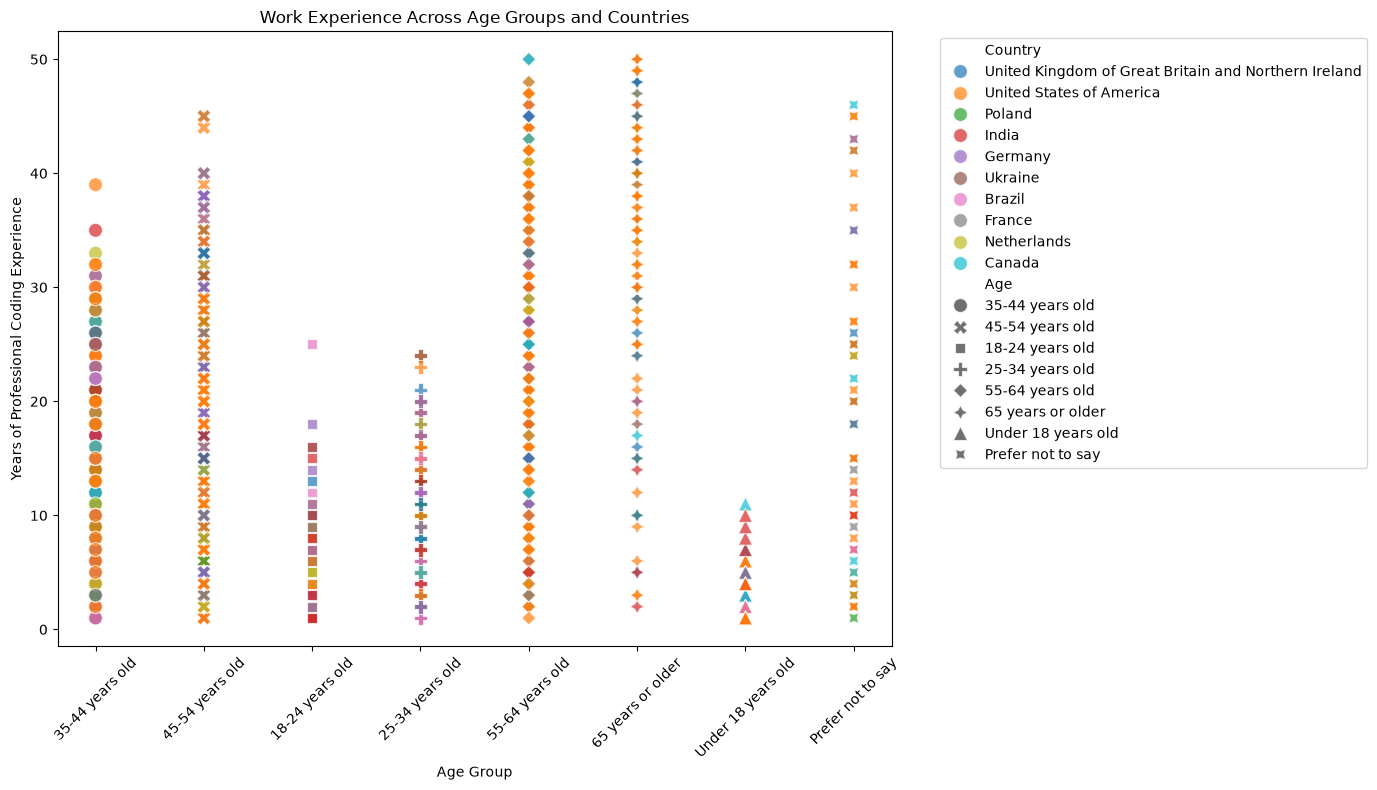

In [13]:
# Select relevant columns
exp_df = df[['Age', 'Country', 'YearsCodePro']].copy()

# Convert YearsCodePro to numeric
exp_df['YearsCodePro'] = pd.to_numeric(
    exp_df['YearsCodePro'],
    errors='coerce'
)

# Remove missing values
exp_df = exp_df.dropna()

# Keep top 10 countries by respondent count
top_10_countries = (
    exp_df['Country']
    .value_counts()
    .nlargest(10)
    .index
)

exp_df = exp_df[
    exp_df['Country'].isin(top_10_countries)
]

# Create scatter plot
plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=exp_df,
    x='Age',
    y='YearsCodePro',
    hue='Country',
    style='Age',
    alpha=0.7,
    s=100
)

plt.title('Work Experience Across Age Groups and Countries')
plt.xlabel('Age Group')
plt.ylabel('Years of Professional Coding Experience')
plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
